## Sine Wave Prediction with LSTM

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

In [2]:
TIMESTEPS = 50
FREQ = 5
POINTS_PER_CYCLE = 100

In [3]:
def generate_sine_data(freq=5, points_per_cycle=100):
    x = np.linspace(0, freq * 2 * np.pi, freq * points_per_cycle)
    y = np.sin(x)

    return y

In [4]:
def prepare_data(data, timesteps):
    X, y = [], []
    for i in range(len(data) - timesteps):
        X.append(data[i:i+timesteps])
        y.append(data[i+timesteps])
    return np.array(X), np.array(y)

data = generate_sine_data(FREQ, POINTS_PER_CYCLE)
data.shape

(500,)

In [5]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1)).flatten()
data.shape



(500,)

In [6]:
X, y = prepare_data(data, TIMESTEPS)
X = X.reshape(X.shape[0], X.shape[1], 1)
y = y.reshape(-1, 1)
X.shape, y.shape

((450, 50, 1), (450, 1))

In [7]:
X[0].shape, y[0].shape

((50, 1), (1,))

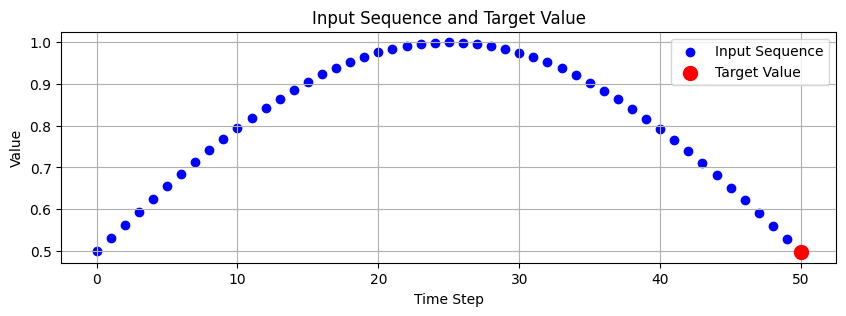

In [8]:
plt.figure(figsize=(10, 3))
plt.scatter(range(len(X[0])), X[0], label='Input Sequence', color='blue')
plt.scatter(len(X[0]), y[0], color='red', s=100, label='Target Value', zorder=5)
plt.legend()
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Input Sequence and Target Value')
plt.grid(True)
plt.show()

In [9]:
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(TIMESTEPS, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, batch_size=32, verbose=1)




I0000 00:00:1748827014.155638   15253 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/kth/venv/mp_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


I0000 00:00:1748827016.396891   18871 cuda_dnn.cc:529] Loaded cuDNN version 90300


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1751
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0300
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0156
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4693e-04
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.9298e-04
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6114e-04
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7409e-05
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5660e-05
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5773e-05
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1737e-05
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9622e-05
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2508e-05
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3

In [10]:
future_steps = TIMESTEPS
last_sequence = data[-TIMESTEPS:]
predicted = []

In [11]:
for _ in range(future_steps):
    input_seq = last_sequence[-TIMESTEPS:].reshape(1, TIMESTEPS, 1)
    pred = model.predict(input_seq, verbose=0)
    predicted.append(pred[0, 0])
    last_sequence = np.append(last_sequence, pred[0, 0])

In [12]:
predicted = scaler.inverse_transform(np.array(predicted).reshape(-1, 1)).flatten()

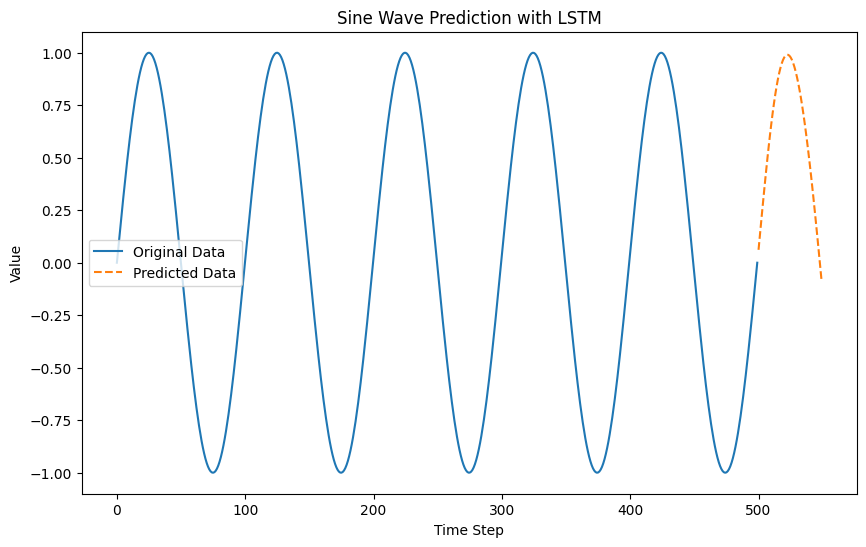

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(data)), scaler.inverse_transform(data.reshape(-1, 1)).flatten(), 
         label='Original Data')
plt.plot(np.arange(len(data), len(data) + len(predicted)), predicted, 
         label='Predicted Data', linestyle='dashed')
plt.legend()
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Sine Wave Prediction with LSTM')
plt.show()

## YOLO + LSTM

### 1. YOLO Train

In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.146 🚀 Python-3.12.3 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 5740MiB)
Setup complete ✅ (12 CPUs, 15.4 GB RAM, 178.8/467.3 GB disk)


In [2]:
import torch

def check_cuda_availability():
    if torch.cuda.is_available():
        print("CUDA is available")
        device = torch.device("cuda")
    else:
        print("CUDA is not available")
        device = torch.device("cpu")
    return device


In [3]:
import platform

print(platform.system())
device = check_cuda_availability()
print(device)

Linux
CUDA is available
cuda


In [7]:
from ultralytics import YOLO
import os
import yaml

data_dir = "/home/kth/robot_dev/mediapipe/data/YOLO_data"
model = 'yolov8n.pt'

classes = ['block', 'hand']
nc = len(classes)
yaml_file = 'data.yaml'

In [8]:
data = {
    'train' : data_dir + '/train/',
    'val' : data_dir + '/vali/',
    'test' : data_dir + '/test/',
    'nc' : nc,
    'names' : classes
}

os.makedirs(data_dir, exist_ok=True)

with open(data_dir + '/' + yaml_file, 'wt') as fw:
    yaml.dump(data, fw)

In [9]:
with open(data_dir + '/' + yaml_file, 'rt') as fr:
    d = yaml.safe_load(fr)
    print(type(d))
    print(d)

<class 'dict'>
{'names': ['block', 'hand'], 'nc': 2, 'test': '/home/kth/robot_dev/mediapipe/data/YOLO_data/test/', 'train': '/home/kth/robot_dev/mediapipe/data/YOLO_data/train/', 'val': '/home/kth/robot_dev/mediapipe/data/YOLO_data/vali/'}


In [10]:
training_epoch = 50
patience = 30
batch = 32
imgsz = 640
optimizer = 'Adam'

In [11]:
model = YOLO(model).to(device)

model.train(data = data_dir + '/' + yaml_file,
            epochs = training_epoch,
            patience = patience,
            batch = batch,
            imgsz = imgsz,
            optimizer = optimizer)

100%|██████████| 6.25M/6.25M [00:00<00:00, 49.4MB/s]


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/kth/robot_dev/mediapipe/data/YOLO_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=30, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=Fal

100%|██████████| 5.35M/5.35M [00:00<00:00, 86.1MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1224.3±804.0 MB/s, size: 49.7 KB)


train: Scanning /home/kth/robot_dev/mediapipe/data/YOLO_data/train/labels... 239 images, 0 backgrounds, 0 corrupt: 100%|██████████| 239/239 [00:00<00:00, 3336.49it/s]

...

                   all         20         40      0.996          1      0.995      0.722



50 epochs completed in 0.039 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.146 🚀 Python-3.12.3 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 5740MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.67it/s]


                   all         20         40      0.972          1      0.995      0.727
                 block         20         20      0.997          1      0.995       0.74
                  hand         20         20      0.946          1      0.995      0.714
Speed: 0.3ms preprocess, 2.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ce50db634a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [12]:
YOLO_best_model_path = './runs/detect/train/weights/best.pt'

YOLO_best_model = YOLO(YOLO_best_model_path).to(device)
metrics = YOLO_best_model.val()

for label, ap in zip(classes, metrics.box.maps):
    print(label, ":", ap)

Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3642.2±791.4 MB/s, size: 51.1 KB)


val: Scanning /home/kth/robot_dev/mediapipe/data/YOLO_data/vali/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]


                   all         20         40      0.971          1      0.995       0.73
                 block         20         20      0.997          1      0.995       0.74
                  hand         20         20      0.945          1      0.995      0.721
Speed: 3.4ms preprocess, 26.0ms inference, 0.0ms loss, 8.4ms postprocess per image
Results saved to runs/detect/val
block : 0.7401315789473685
hand : 0.7206180555555555


### 2. Data Ready